Klasifikasi Penyakit Kulit Berdasarkan Data Klinis

    1: "Psoriasis",
    2: "Seborrheic Dermatitis",
    3: "Lichen Planus",
    4: "Pityriasis Rosea",
    5: "Chronic Dermatitis",
    6: "Pityriasis Rubra Pilaris"

> Add blockquote



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

1. DATA UNDERSTANDING

In [2]:
# Load dataset
df = pd.read_csv('/content/dermatology_database_1.csv')

# Lihat data awal

print(df.head())


   erythema  scaling  definite_borders  itching  koebner_phenomenon  \
0         2        2                 0        3                   0   
1         3        3                 3        2                   1   
2         2        1                 2        3                   1   
3         2        2                 2        0                   0   
4         2        3                 2        2                   2   

   polygonal_papules  follicular_papules  oral_mucosal_involvement  \
0                  0                   0                         0   
1                  0                   0                         0   
2                  3                   0                         3   
3                  0                   0                         0   
4                  2                   0                         2   

   knee_and_elbow_involvement  scalp_involvement  ...  \
0                           1                  0  ...   
1                           1         

In [3]:
print(df.nunique())

erythema                                4
scaling                                 4
definite_borders                        4
itching                                 4
koebner_phenomenon                      4
polygonal_papules                       4
follicular_papules                      4
oral_mucosal_involvement                4
knee_and_elbow_involvement              4
scalp_involvement                       4
family_history                          2
melanin_incontinence                    4
eosinophils_infiltrate                  3
PNL_infiltrate                          4
fibrosis_papillary_dermis               4
exocytosis                              4
acanthosis                              4
hyperkeratosis                          4
parakeratosis                           4
clubbing_rete_ridges                    4
elongation_rete_ridges                  4
thinning_suprapapillary_epidermis       4
spongiform_pustule                      4
munro_microabcess                 

In [4]:
# Info dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   erythema                             366 non-null    int64 
 1   scaling                              366 non-null    int64 
 2   definite_borders                     366 non-null    int64 
 3   itching                              366 non-null    int64 
 4   koebner_phenomenon                   366 non-null    int64 
 5   polygonal_papules                    366 non-null    int64 
 6   follicular_papules                   366 non-null    int64 
 7   oral_mucosal_involvement             366 non-null    int64 
 8   knee_and_elbow_involvement           366 non-null    int64 
 9   scalp_involvement                    366 non-null    int64 
 10  family_history                       366 non-null    int64 
 11  melanin_incontinence                 366 non-

In [5]:
# Statistik deskriptif
print(df.describe())

         erythema     scaling  definite_borders     itching  \
count  366.000000  366.000000        366.000000  366.000000   
mean     2.068306    1.795082          1.549180    1.366120   
std      0.664753    0.701527          0.907525    1.138299   
min      0.000000    0.000000          0.000000    0.000000   
25%      2.000000    1.000000          1.000000    0.000000   
50%      2.000000    2.000000          2.000000    1.000000   
75%      2.000000    2.000000          2.000000    2.000000   
max      3.000000    3.000000          3.000000    3.000000   

       koebner_phenomenon  polygonal_papules  follicular_papules  \
count          366.000000         366.000000          366.000000   
mean             0.633880           0.448087            0.166667   
std              0.908016           0.957327            0.570588   
min              0.000000           0.000000            0.000000   
25%              0.000000           0.000000            0.000000   
50%              0.00000

In [6]:
df.isnull().sum()

,0
erythema,0
scaling,0
definite_borders,0
itching,0
koebner_phenomenon,0
polygonal_papules,0
follicular_papules,0
oral_mucosal_involvement,0
knee_and_elbow_involvement,0
scalp_involvement,0


In [7]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


2. DATA PREPROCESSING

In [8]:
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric)

imputer = SimpleImputer(strategy='median')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print(df.isnull().sum())

erythema                               0
scaling                                0
definite_borders                       0
itching                                0
koebner_phenomenon                     0
polygonal_papules                      0
follicular_papules                     0
oral_mucosal_involvement               0
knee_and_elbow_involvement             0
scalp_involvement                      0
family_history                         0
melanin_incontinence                   0
eosinophils_infiltrate                 0
PNL_infiltrate                         0
fibrosis_papillary_dermis              0
exocytosis                             0
acanthosis                             0
hyperkeratosis                         0
parakeratosis                          0
clubbing_rete_ridges                   0
elongation_rete_ridges                 0
thinning_suprapapillary_epidermis      0
spongiform_pustule                     0
munro_microabcess                      0
focal_hypergranu

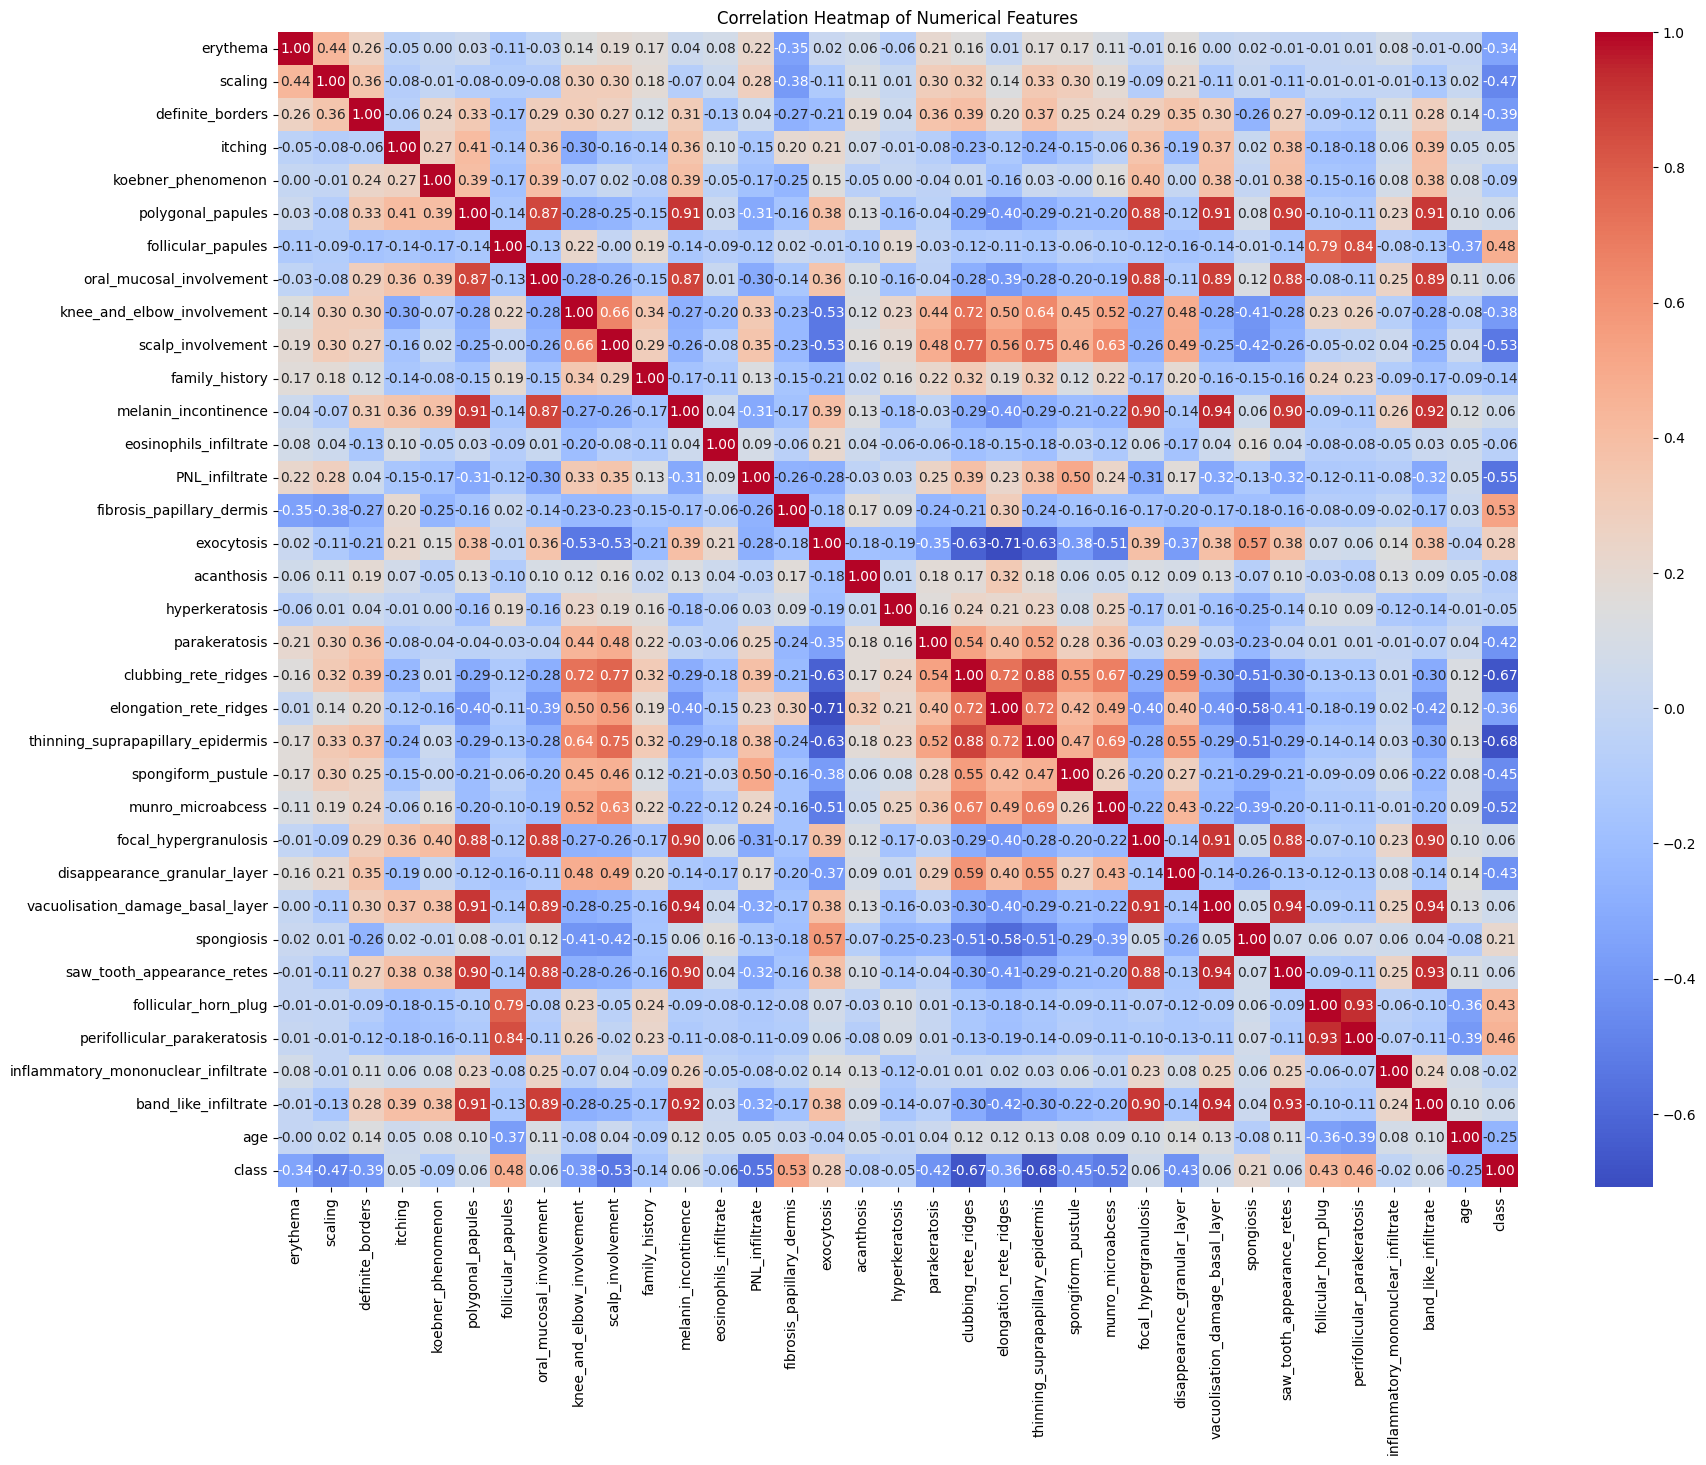

In [9]:
# Select only numerical columns for correlation calculation
numerical_data = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()

# Plotting the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

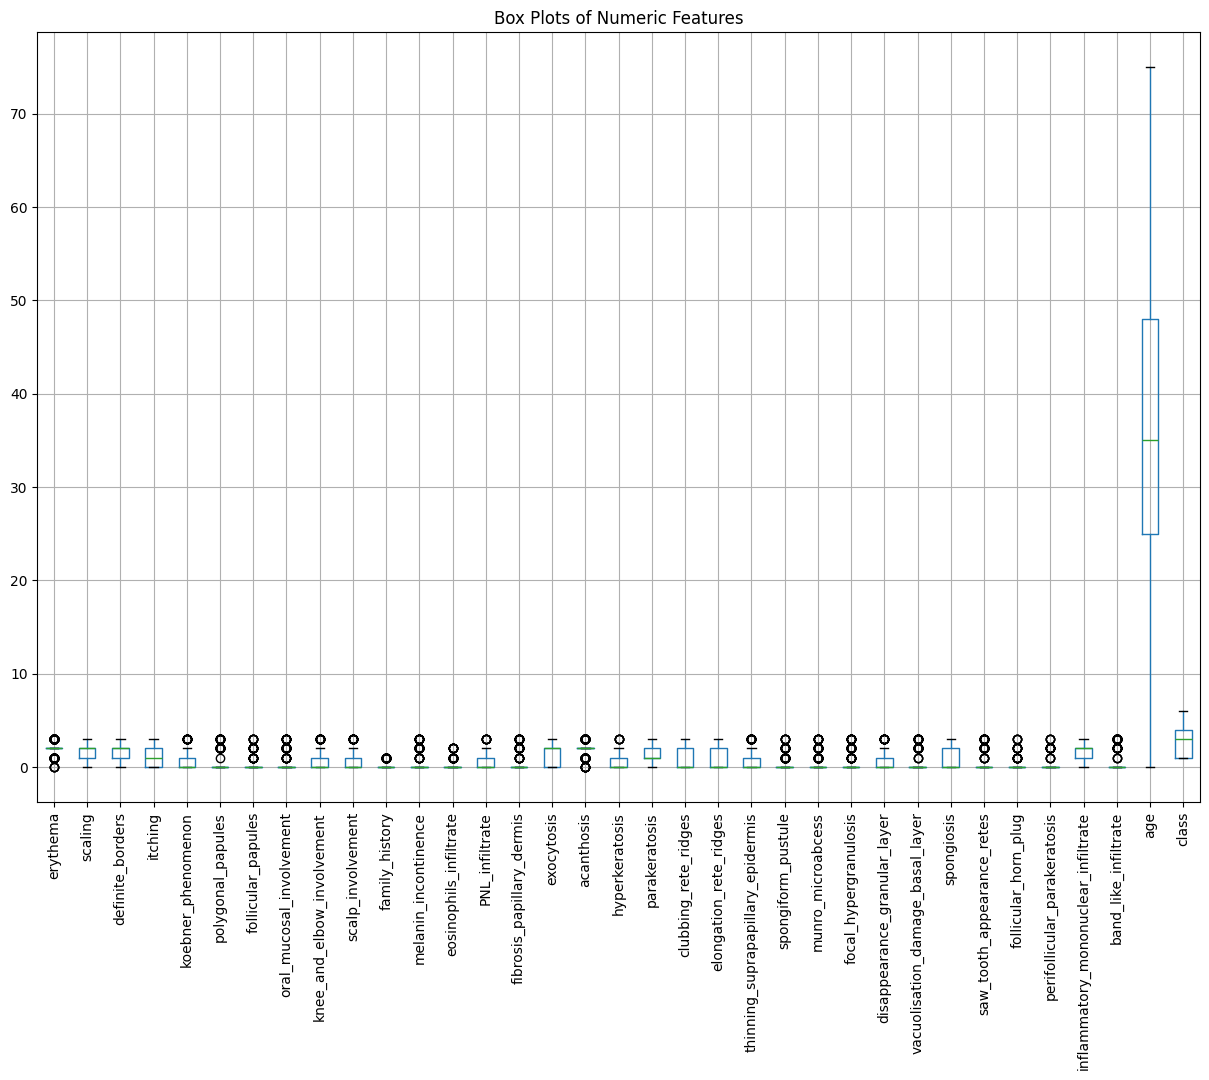

In [10]:
# Tentukan kolom numerik/ untuk memilih kolom numerik saja
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns

# Lalu buat boxplot/ untuk melihat data, melihat data outlier
plt.figure(figsize=(15, 10))
df[numeric_features].boxplot()
plt.title('Box Plots of Numeric Features')
plt.xticks(rotation=90)
plt.show()

In [11]:
col = 'age'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower) | (df[col] > upper)]

print("Jumlah outlier:", len(outliers))
print(outliers[['age']])

Jumlah outlier: 0
Empty DataFrame
Columns: [age]
Index: []


pisah fitur dan target

In [12]:
X = df.drop('class', axis=1)
y = df['class']

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

3. EXPLORATORY DATA ANALYSIS (EDA)

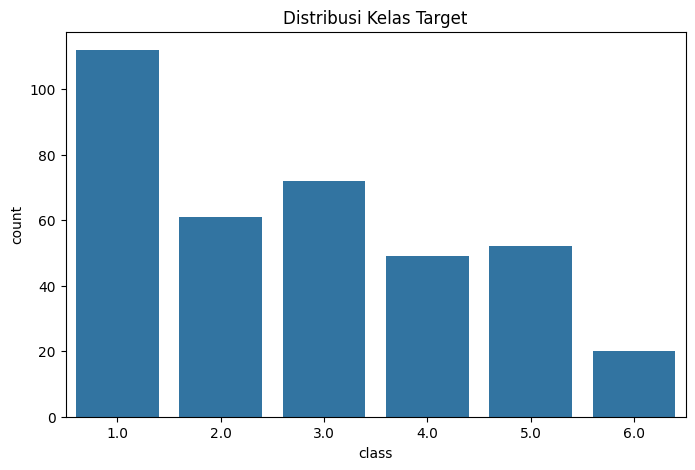

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['class'])
plt.title("Distribusi Kelas Target")
plt.show()

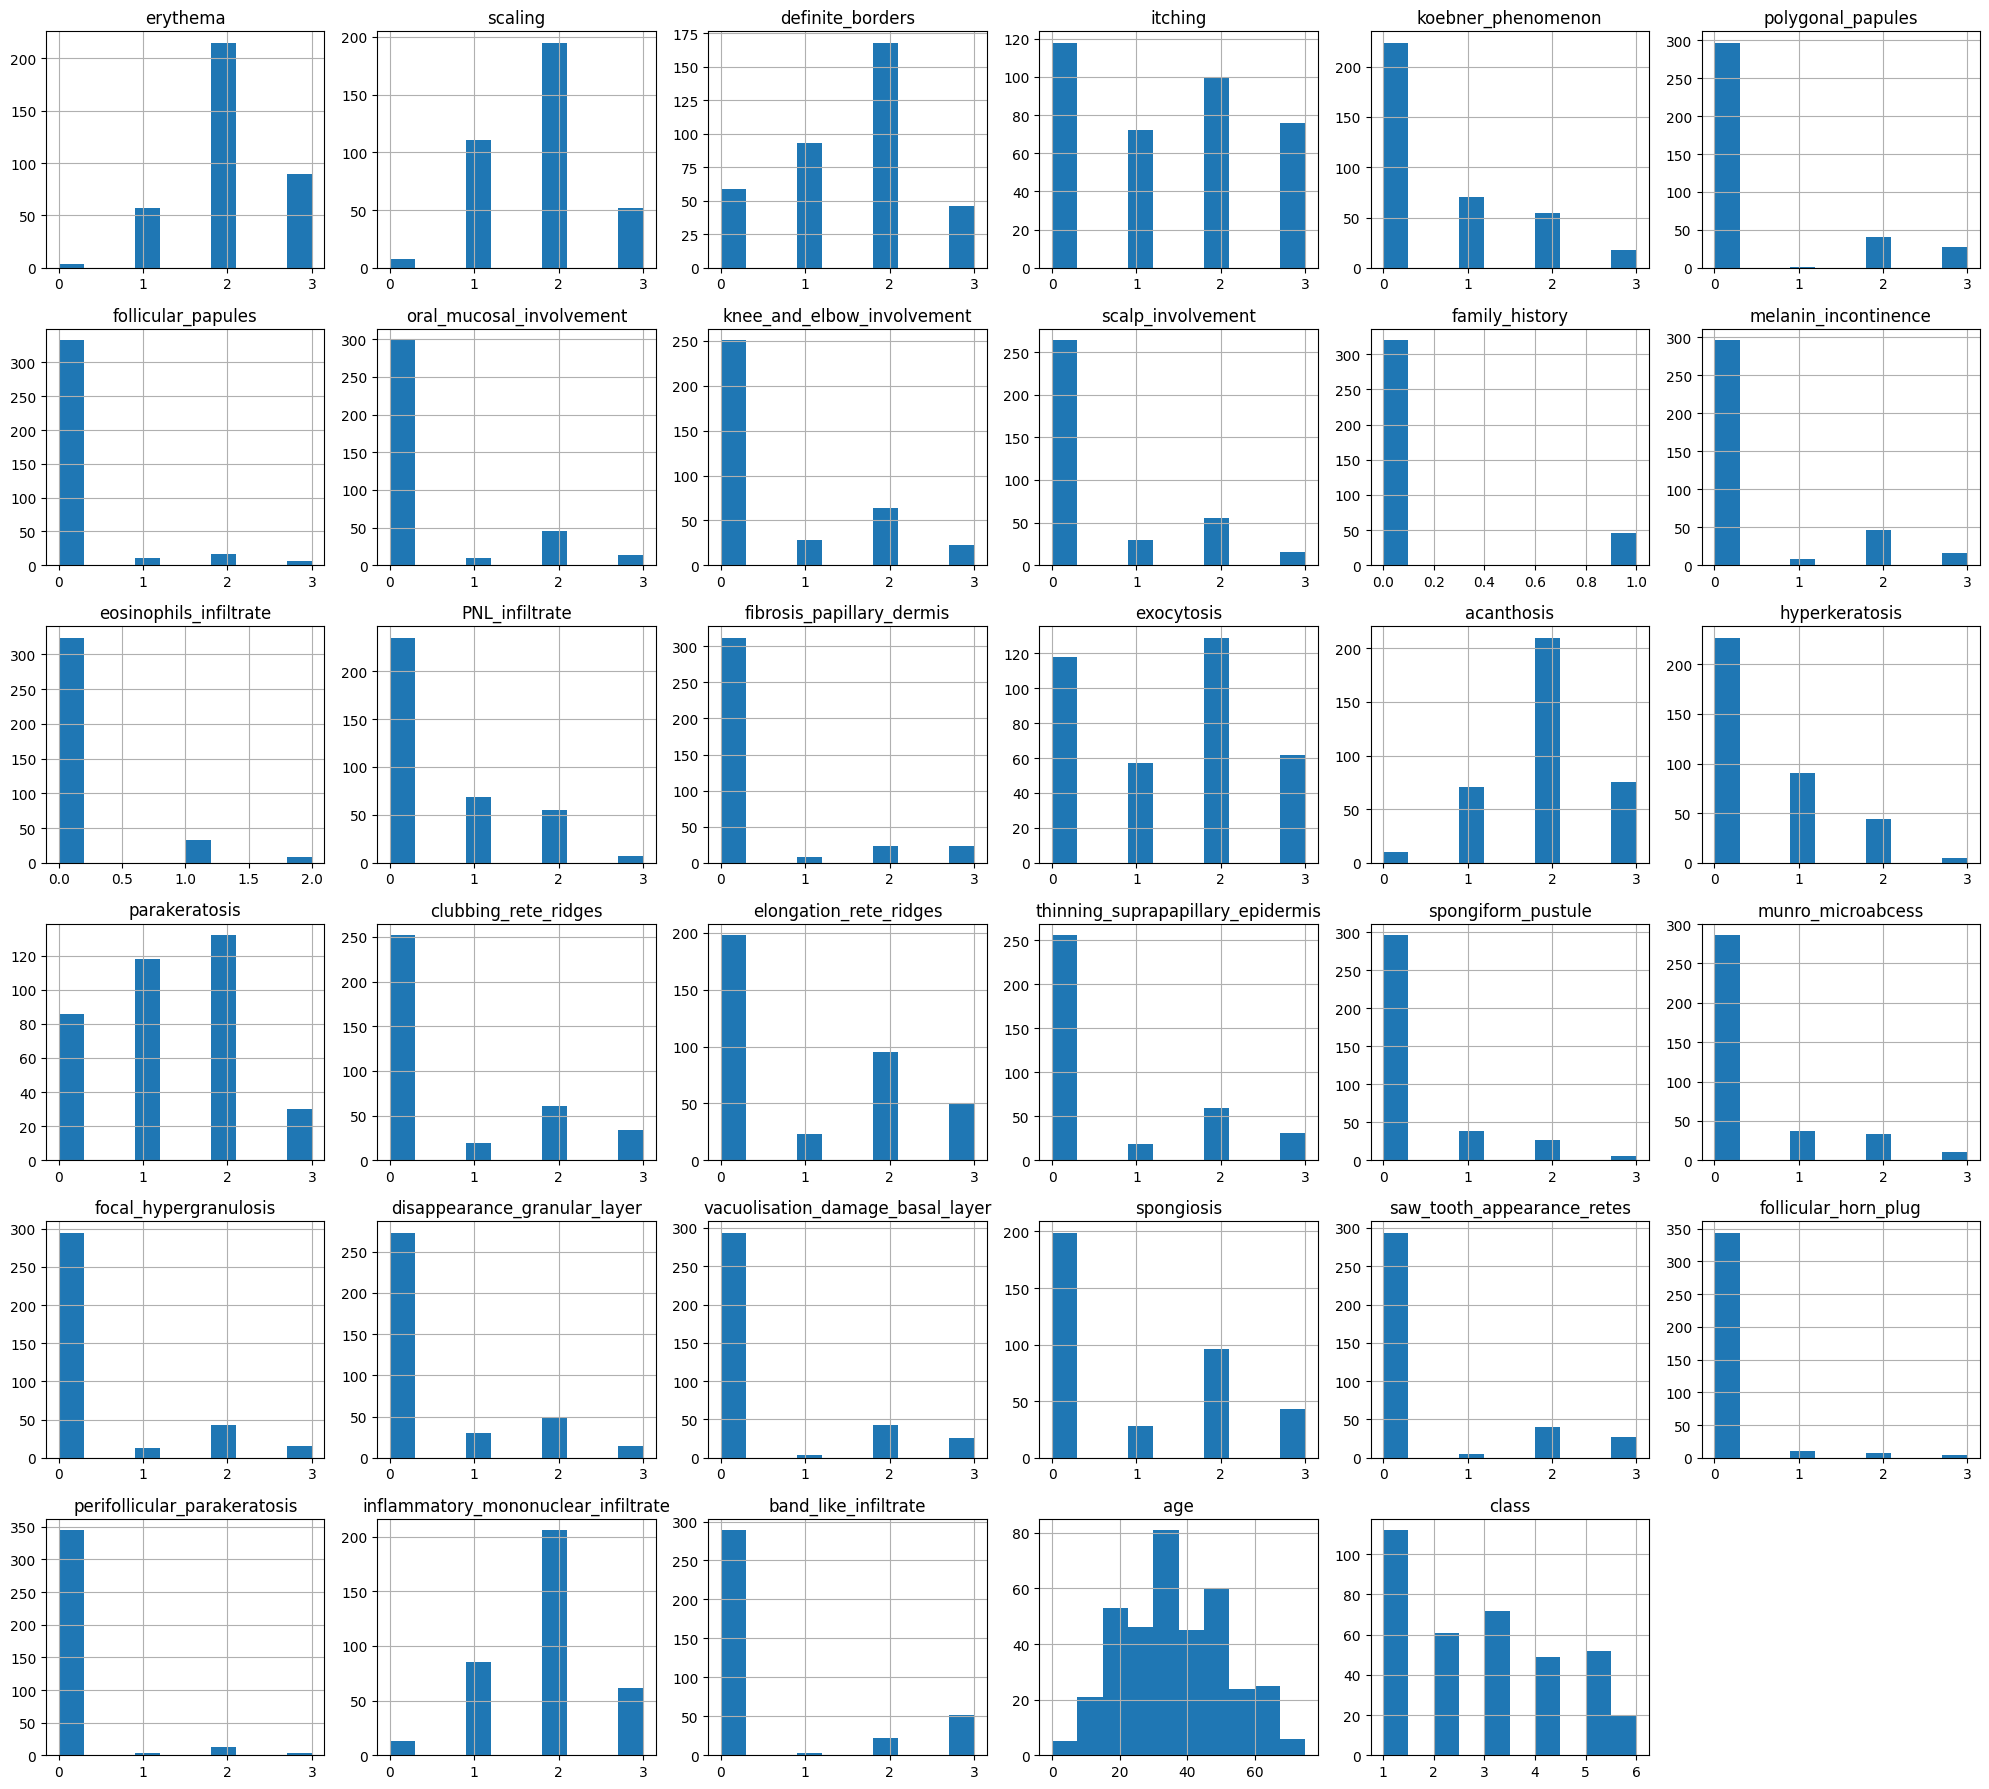

In [15]:
df.hist(figsize=(20,18))
plt.tight_layout()
plt.show()

4. DATA SPLITTING

In [16]:
splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

tangani data imbalance

In [17]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

data_splits = {}

for split_name, test_size in splits.items():

    print(f"\n=== SPLIT {split_name} ===")

    # SPLIT DATA
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # SMOTE (HANYA TRAIN)
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    # SIMPAN
    data_splits[split_name] = {
        "X_train": X_train_smote,
        "y_train": y_train_smote,
        "X_test": X_test,
        "y_test": y_test
    }

    print("Sebelum SMOTE:", y_train.value_counts().to_dict())
    print("Sesudah SMOTE:", y_train_smote.value_counts().to_dict())


=== SPLIT 70:30 ===
Sebelum SMOTE: {1.0: 78, 3.0: 50, 2.0: 43, 5.0: 37, 4.0: 34, 6.0: 14}
Sesudah SMOTE: {1.0: 78, 4.0: 78, 3.0: 78, 2.0: 78, 5.0: 78, 6.0: 78}

=== SPLIT 80:20 ===
Sebelum SMOTE: {1.0: 89, 3.0: 57, 2.0: 49, 5.0: 42, 4.0: 39, 6.0: 16}
Sesudah SMOTE: {3.0: 89, 5.0: 89, 4.0: 89, 1.0: 89, 2.0: 89, 6.0: 89}

=== SPLIT 90:10 ===
Sebelum SMOTE: {1.0: 100, 3.0: 65, 2.0: 55, 5.0: 47, 4.0: 44, 6.0: 18}
Sesudah SMOTE: {6.0: 100, 3.0: 100, 2.0: 100, 4.0: 100, 5.0: 100, 1.0: 100}


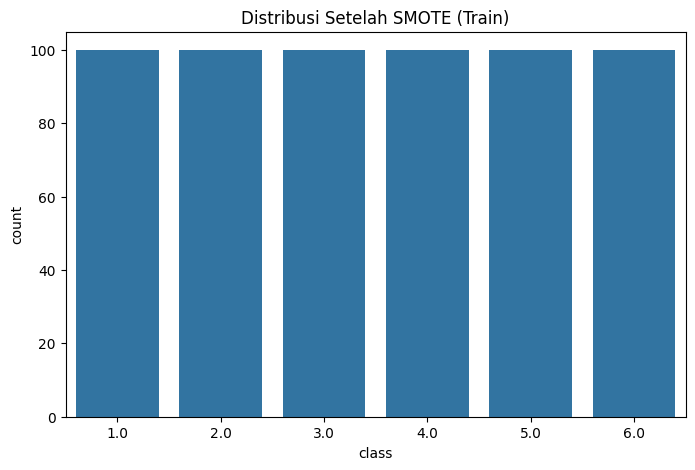

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x=y_train_smote)
plt.title("Distribusi Setelah SMOTE (Train)")
plt.show()

5. MODELING + HYPERPARAMETER TUNING

In [19]:
results = []

for split_name, test_size in splits.items():

    print(f"\n========== SPLIT {split_name} ==========\n")

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # Logistic Regression
    param_lr = {'C':[0.1,1,10]}
    grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_lr, cv=5)
    grid_lr.fit(X_train, y_train)
    pred_lr = grid_lr.predict(X_test)
    acc_lr = accuracy_score(y_test, pred_lr)

    # Decision Tree
    param_dt = {'max_depth':[3,5,10,None]}
    grid_dt = GridSearchCV(DecisionTreeClassifier(), param_dt, cv=5)
    grid_dt.fit(X_train, y_train)
    pred_dt = grid_dt.predict(X_test)
    acc_dt = accuracy_score(y_test, pred_dt)

    # Random Forest
    param_rf = {
        'n_estimators':[50,100,200],
        'max_depth':[5,10,None]
    }
    grid_rf = GridSearchCV(RandomForestClassifier(), param_rf, cv=5)
    grid_rf.fit(X_train, y_train)
    pred_rf = grid_rf.predict(X_test)
    acc_rf = accuracy_score(y_test, pred_rf)

    results.append([split_name, "Logistic Regression", acc_lr])
    results.append([split_name, "Decision Tree", acc_dt])
    results.append([split_name, "Random Forest", acc_rf])


========== SPLIT 70:30 ==========


========== SPLIT 80:20 ==========


========== SPLIT 90:10 ==========



6. EVALUASI MODEL

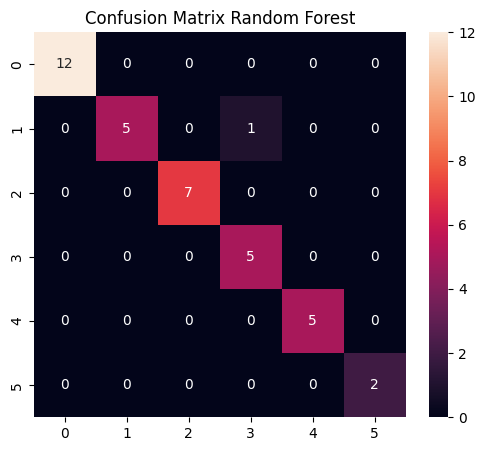

In [20]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix Random Forest")
plt.show()

In [21]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00        12
         2.0       1.00      0.83      0.91         6
         3.0       1.00      1.00      1.00         7
         4.0       0.83      1.00      0.91         5
         5.0       1.00      1.00      1.00         5
         6.0       1.00      1.00      1.00         2

    accuracy                           0.97        37
   macro avg       0.97      0.97      0.97        37
weighted avg       0.98      0.97      0.97        37



In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

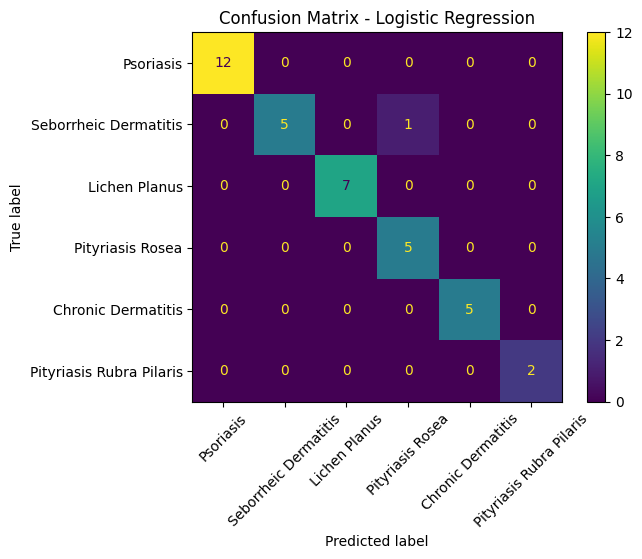

In [23]:
# ==============================
# CONFUSION MATRIX LOGISTIC REGRESSION
# ==============================
cm_lr = confusion_matrix(y_test, pred_lr)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=[
        "Psoriasis",
        "Seborrheic Dermatitis",
        "Lichen Planus",
        "Pityriasis Rosea",
        "Chronic Dermatitis",
        "Pityriasis Rubra Pilaris"
    ]
)
disp_lr.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.xticks(rotation=45)
plt.show()


7. PERBANDINGAN MODEL

In [24]:
result_df = pd.DataFrame(results, columns=['Split', 'Model', 'Accuracy'])
print(result_df)

   Split                Model  Accuracy
0  70:30  Logistic Regression  0.981818
1  70:30        Decision Tree  0.918182
2  70:30        Random Forest  0.981818
3  80:20  Logistic Regression  0.959459
4  80:20        Decision Tree  0.891892
5  80:20        Random Forest  0.959459
6  90:10  Logistic Regression  0.972973
7  90:10        Decision Tree  0.945946
8  90:10        Random Forest  0.972973


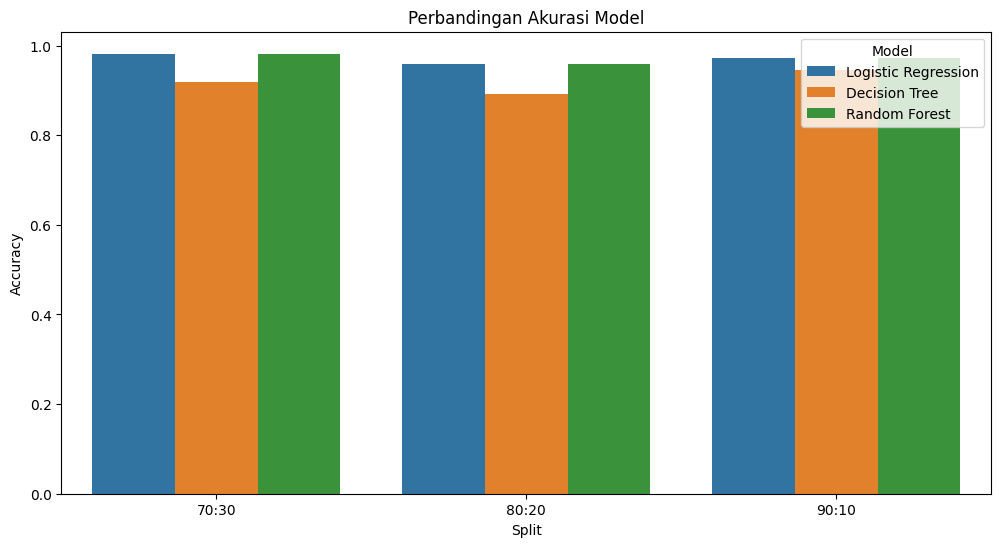

In [25]:
plt.figure(figsize=(12,6))
sns.barplot(data=result_df, x='Split', y='Accuracy', hue='Model')
plt.title("Perbandingan Akurasi Model")
plt.show()

In [26]:
best_model = result_df.loc[result_df['Accuracy'].idxmax()]
print("Model Terbaik:")
print(best_model)

Model Terbaik:
Split                     70:30
Model       Logistic Regression
Accuracy               0.981818
Name: 0, dtype: object


inferensi


In [27]:
# ============================
# LABEL
# ============================
label_penyakit = {
    1: "Psoriasis",
    2: "Seborrheic Dermatitis",
    3: "Lichen Planus",
    4: "Pityriasis Rosea",
    5: "Chronic Dermatitis",
    6: "Pityriasis Rubra Pilaris"
}

# ============================
# DATA BARU
# ============================
data_baru = [[
    2, 2, 1, 3, 0, 0, 0, 0, 1, 1,
    0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
    0, 1, 0, 35
]]

# ============================
# SCALING
# ============================
data_baru_scaled = scaler.transform(data_baru)

# ============================
# PREDIKSI
# ============================
pred = grid_rf.predict(data_baru_scaled)[0]

# ============================
# OUTPUT
# ============================
print("Kode Prediksi:", pred)
print("Jenis Penyakit:", label_penyakit[pred])

Kode Prediksi: 1.0
Jenis Penyakit: Psoriasis


In [28]:
import joblib

#  model terbaik (contoh Random Forest)
joblib.dump(grid_rf.best_estimator_, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [35]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib

# Load model & scaler
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

st.title("Prediksi Penyakit Kulit")

st.write("Masukkan nilai klinis (0–3) sesuai kondisi pasien")

# =========================
# INPUT SEMUA FITUR (34)
# =========================
features = []

features.append(st.slider("erythema", 0, 3, 1))
features.append(st.slider("scaling", 0, 3, 1))
features.append(st.slider("definite_borders", 0, 3, 1))
features.append(st.slider("itching", 0, 3, 1))
features.append(st.slider("koebner_phenomenon", 0, 3, 0))
features.append(st.slider("polygonal_papules", 0, 3, 0))
features.append(st.slider("follicular_papules", 0, 3, 0))
features.append(st.slider("oral_mucosal_involvement", 0, 3, 0))
features.append(st.slider("knee_and_elbow_involvement", 0, 3, 0))
features.append(st.slider("scalp_involvement", 0, 3, 0))
features.append(st.selectbox("family_history", [0,1]))
features.append(st.slider("melanin_incontinence", 0, 3, 0))
features.append(st.slider("eosinophils_infiltrate", 0, 3, 0))
features.append(st.slider("PNL_infiltrate", 0, 3, 0))
features.append(st.slider("fibrosis_papillary_dermis", 0, 3, 0))
features.append(st.slider("exocytosis", 0, 3, 0))
features.append(st.slider("acanthosis", 0, 3, 0))
features.append(st.slider("hyperkeratosis", 0, 3, 0))
features.append(st.slider("parakeratosis", 0, 3, 0))
features.append(st.slider("clubbing_rete_ridges", 0, 3, 0))
features.append(st.slider("elongation_rete_ridges", 0, 3, 0))
features.append(st.slider("thinning_suprapapillary_epidermis", 0, 3, 0))
features.append(st.slider("spongiform_pustule", 0, 3, 0))
features.append(st.slider("munro_microabcess", 0, 3, 0))
features.append(st.slider("focal_hypergranulosis", 0, 3, 0))
features.append(st.slider("disappearance_granular_layer", 0, 3, 0))
features.append(st.slider("vacuolisation_damage_basal_layer", 0, 3, 0))
features.append(st.slider("spongiosis", 0, 3, 0))
features.append(st.slider("saw_tooth_appearance_retes", 0, 3, 0))
features.append(st.slider("follicular_horn_plug", 0, 3, 0))
features.append(st.slider("perifollicular_parakeratosis", 0, 3, 0))
features.append(st.slider("inflammatory_mononuclear_infiltrate", 0, 3, 1))
features.append(st.slider("band_like_infiltrate", 0, 3, 0))
features.append(st.number_input("age", 0, 100, 30))

# =========================
# LABEL PENYAKIT
# =========================
label_penyakit = {
    1: "Psoriasis",
    2: "Seborrheic Dermatitis",
    3: "Lichen Planus",
    4: "Pityriasis Rosea",
    5: "Chronic Dermatitis",
    6: "Pityriasis Rubra Pilaris"
}

# =========================
# PREDIKSI
# =========================
if st.button("Prediksi"):
    input_data = np.array([features])
    input_scaled = scaler.transform(input_data)

    pred = model.predict(input_scaled)[0]

    st.success(f"Hasil Prediksi: {label_penyakit[int(pred)]}")

Overwriting app.py


In [36]:
!pip install streamlit pyngrok

In [37]:
!ngrok config add-authtoken 3ChFnHAzX2WJ251k5OVZ4hbnUPA_2MdNVohbBpJVsBJMGTGuL

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [38]:
!pip install pyngrok --quiet

from pyngrok import ngrok

# matikan streamlit lama
!pkill -f streamlit

# jalankan streamlit di background
import subprocess
subprocess.Popen(["streamlit", "run", "app.py"])

# buka tunnel
public_url = ngrok.connect(8501, "http")
print("Link Streamlit kamu:", public_url)

Link Streamlit kamu: NgrokTunnel: "https://showpiece-fiddle-cold.ngrok-free.dev" -> "http://localhost:8501"


In [32]:
%%writefile requirements.txt
streamlit
scikit-learn
numpy
joblib

Writing requirements.txt


In [39]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [44]:
!git config --global user.email "satrianinis484@gmail.com"
!git config --global user.name "nss"

In [45]:
!git add .
!git commit -m "first commit"
!git remote add origin https://github.com/Wolfultra02/Projek-Mini.git

[master (root-commit) c9def9a] first commit
 35 files changed, 51671 insertions(+)
 create mode 100644 .config/.last_opt_in_prompt.yaml
 create mode 100644 .config/.last_survey_prompt.yaml
 create mode 100644 .config/.last_update_check.json
 create mode 100644 .config/active_config
 create mode 100644 .config/config_sentinel
 create mode 100644 .config/configurations/config_default
 create mode 100644 .config/default_configs.db
 create mode 100644 .config/gce
 create mode 100644 .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
 create mode 100644 .config/logs/2026.04.16/13.27.28.140888.log
 create mode 100644 .config/logs/2026.04.16/13.27.53.684484.log
 create mode 100644 .config/logs/2026.04.16/13.28.05.189231.log
 create mode 100644 .config/logs/2026.04.16/13.28.06.952902.log
 create mode 100644 .config/logs/2026.04.16/13.28.21.827521.log
 create mode 100644 .config/logs/2026.04.16/13.28.22.950479.log
 create mode 100644 app.py
 create mode 100644 dermatology_da

In [46]:
!git push -u origin main

error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/Wolfultra02/Projek-Mini.git'
